In [66]:
# https://www.kaggle.com/code/rhodiumbeng/classifying-multi-label-comments-0-9741-lb

In [67]:
import warnings
warnings.simplefilter("ignore")

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [69]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load data

In [70]:
df = pd.read_csv('train.csv')

In [71]:
df.sample(5)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
85775,e57176299730fad9,One might say the same about insisting to use ...,0,0,0,0,0,0
67257,b3ee681c8cac5df1,"Poppers image \n\nHi Manatobe, thanks for your...",0,0,0,0,0,0
106319,38dd44c168b3ae07,"Thanks, I've put it (with bat god) upfor DYK.",0,0,0,0,0,0
34025,5ac8436e5e1bc440,"POTD notification \n\n]]\nHi Keuranoscopia,\n\...",0,0,0,0,0,0
136507,da4dce7f1217800a,March 2012 (UTC)\nright on. Great idea to use ...,0,0,0,0,0,0


In [72]:
df.shape

(159571, 8)

# 2. Check data quality

data type

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


unique value

In [74]:
for i in df.columns:
    print('Columns name: ', i)
    print('Unique value: ', df[i].unique())
    print('Count unique value: ', df[i].nunique())
    print('-'*10)

Columns name:  id
Unique value:  ['0000997932d777bf' '000103f0d9cfb60f' '000113f07ec002fd' ...
 'ffee36eab5c267c9' 'fff125370e4aaaf3' 'fff46fc426af1f9a']
Count unique value:  159571
----------
Columns name:  comment_text
Unique value:  ["Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27"
 "D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)"
 "Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info."
 ...
 'Spitzer \n\nUmm, theres no actual article for prostitution ring.  - Crunch Captain.'
 'And it looks like it was actually you who put on

missing value

In [75]:
df.isna().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

# 3. Exploratory data analysis (EDA)

In [76]:
target_col = ['obscene','insult','toxic','severe_toxic','identity_hate','threat']

In [77]:
df[target_col].describe()

,obscene,insult,toxic,severe_toxic,identity_hate,threat
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.052948,0.049364,0.095844,0.009996,0.008805,0.002996
std,0.223931,0.216627,0.294379,0.099477,0.093420,0.054650
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


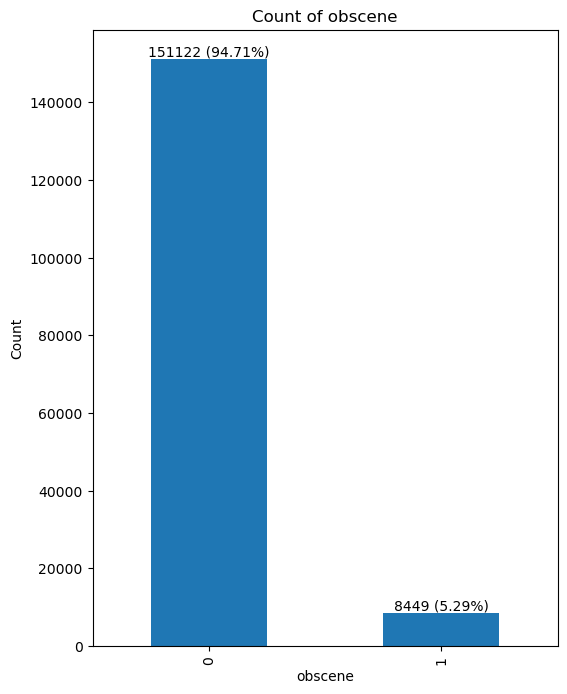

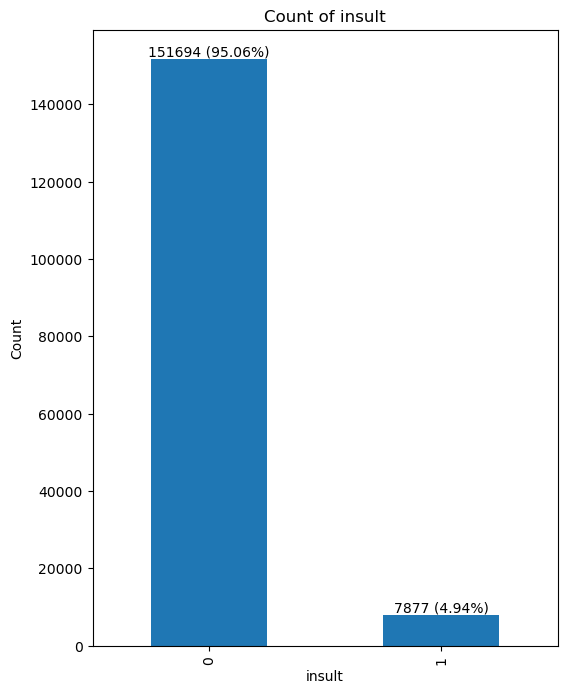

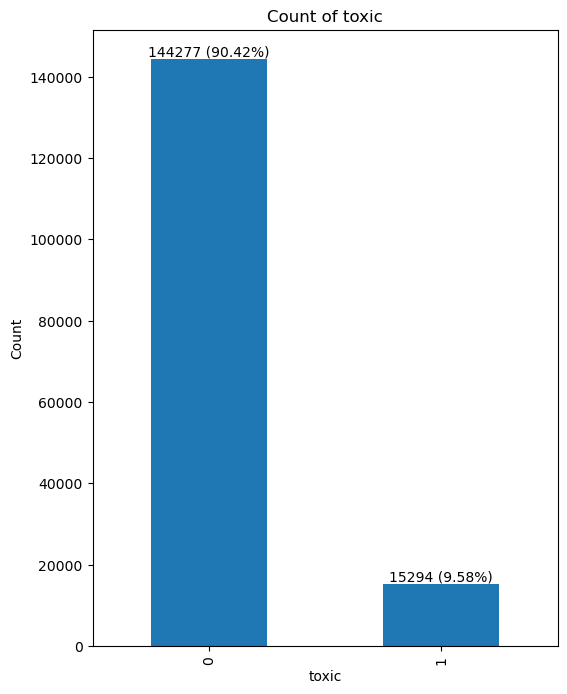

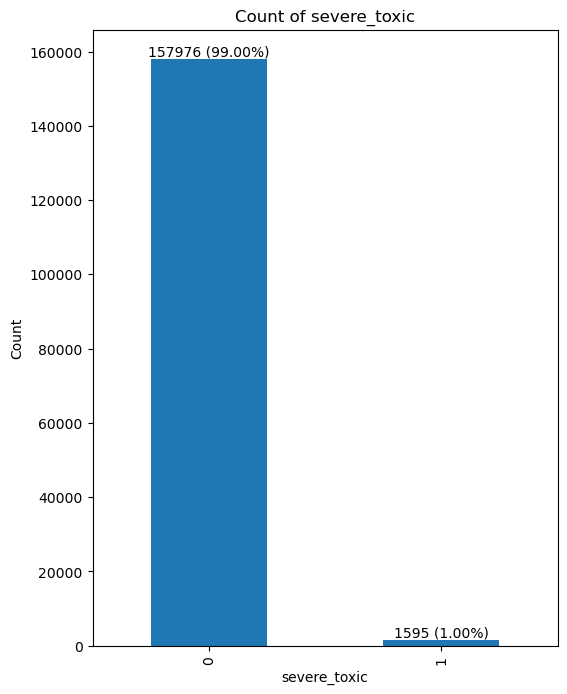

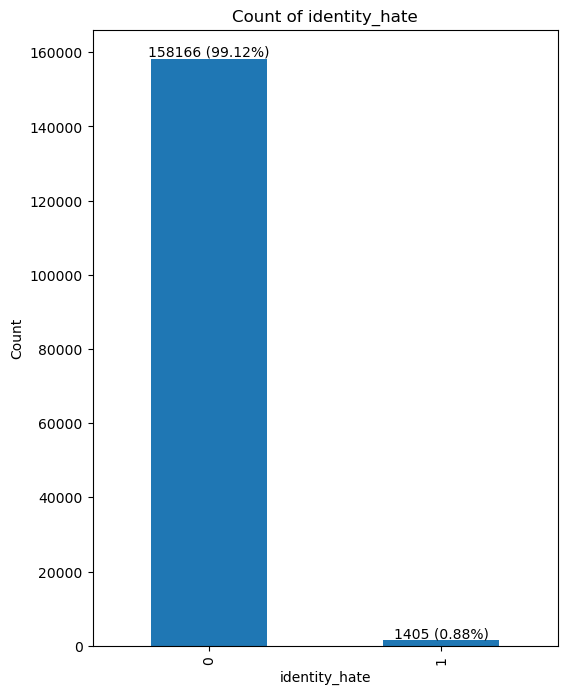

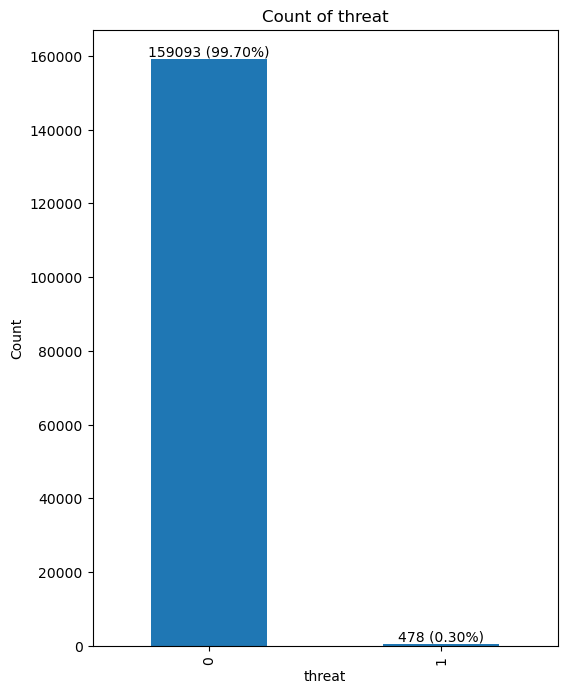

In [78]:
for column in target_col:
    category_counts = df[column].value_counts()
    total_count = len(df[column])
    plt.figure(figsize=(6, 8))
    ax = category_counts.plot(kind='bar')
    for i, count in enumerate(category_counts):
        percentage = (count / total_count) * 100
        ax.annotate(f'{count} ({percentage:.2f}%)', xy=(i, count), ha='center', va='bottom')
    
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.title(f'Count of {column}')
    plt.show()

In [79]:
# All the class facing with imbalance problem.

In [80]:
df['length'] = df['comment_text'].apply(lambda x: len(str(x)))

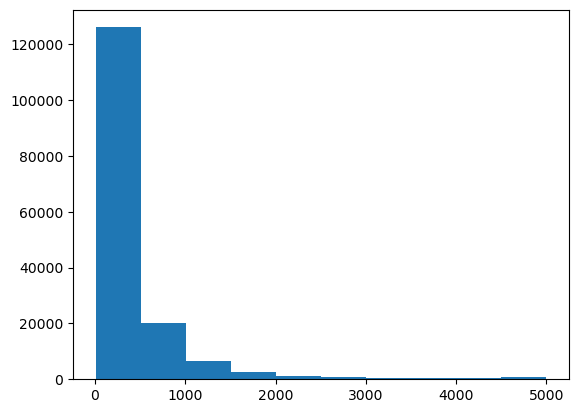

In [81]:
plt.figure()
plt.hist(df['length'])
plt.show()

In [82]:
# Some messages are over than 5000 words.

In [83]:
target_corr = df[target_col].corr()

<Axes: >

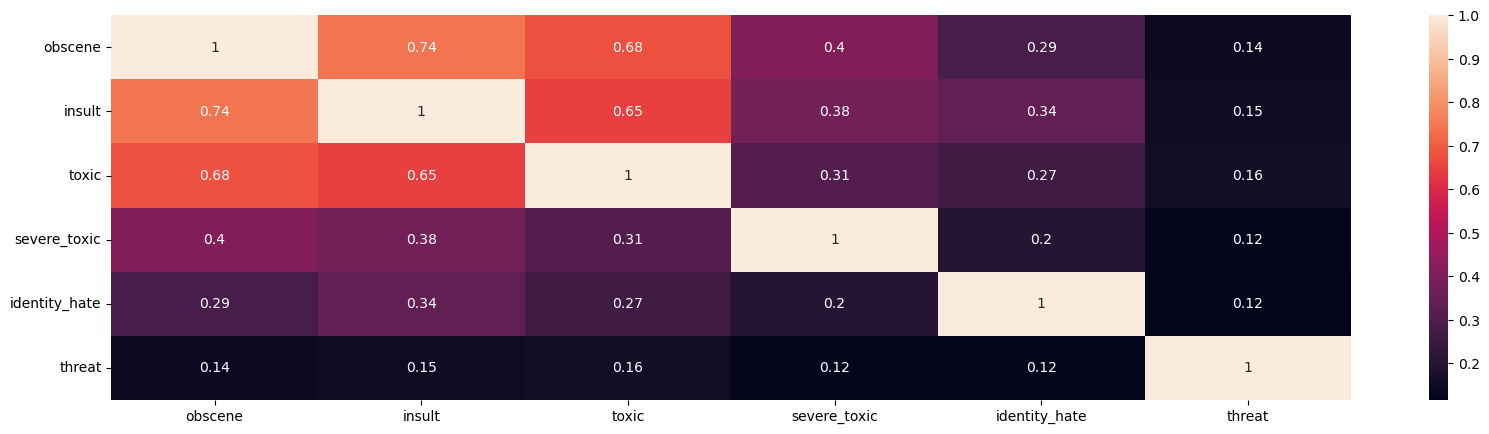

In [84]:
fig, ax = plt.subplots(figsize=(20, 5))
sns.heatmap(target_corr, annot=True, ax=ax)

In [85]:
# Some of the labels are higher correlation such as obscene-insult/obscene-toxic/toxic-insult
# Classifier Chains would be good ?

# 4. Feature engineering

clean data

In [86]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "cannot ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)
    text = re.sub('\W', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip(' ')
    return text

In [87]:
df['comment_text'] = df['comment_text'].map(lambda com : clean_text(com))

In [88]:
df.sample(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,length
22180,3a80c2b65e843cae,i think it a witty reference to me living in s...,0,0,0,0,0,0,69
142132,f84ac99d37583e14,could someone edit a page please could someone...,0,0,0,0,0,0,117
55397,940229e5f76220f5,again if you find these additions objectionabl...,0,0,0,0,0,0,368
10484,1bb0087f8111a96a,ìɥáinsert non formatted text hereinsert non fo...,0,0,0,0,0,0,98
98676,0fe917cf1bfab0bc,it seems the process requires a deletion nomin...,0,0,0,0,0,0,157
142599,fabb5572558ab51b,as it is now this motherfucking asshole keeps ...,1,0,1,0,1,0,91
74833,c82f686e0acd742e,your threatening behaviour your constant block...,1,0,0,0,1,0,391
34413,5beada762b2acfa7,sorting and proper english wp sort reads in pa...,0,0,0,0,0,0,476
122631,8ffe1f7e3a00dc45,a john poole i have added a prod template to t...,0,0,0,0,0,0,927
49126,835763303503f42c,i agree she should not be labeled an incumbent...,0,0,0,0,0,0,1340


# 5. Model

Train/Test Split

In [89]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(df[['comment_text']], df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']]
                                                    ,test_size=0.2
                                                    ,random_state=42)

In [90]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(127656, 1)
(127656, 6)
(31915, 1)
(31915, 6)


Vectorization/TD-IDF

In [91]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1,1))

In [92]:
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf= TfidfVectorizer()

In [94]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [95]:
***

SyntaxError: invalid syntax (2938429678.py, line 1)

In [101]:
def add_feature(X, feature_to_add):
    '''
    Returns sparse feature matrix with added feature.
    feature_to_add can also be a list of features.
    '''
    from scipy.sparse import csr_matrix, hstack
    return hstack([X, csr_matrix(feature_to_add).T], 'csr')

Model (Vectorization)

In [96]:
# import and instantiate the Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
logreg = LogisticRegression(C=12.0)

In [100]:
for label in target_col:
    print('... Processing {}'.format(label))
    y = y_test[label]
    # train the model using X_dtm & y
    logreg.fit(X_train_tfidf, y)
    # compute the training accuracy
    y_pred_X = logreg.predict(X_test_tfidf)
    print('Training accuracy is {}'.format(accuracy_score(y, y_pred_X)))

... Processing obscene


ValueError: Found input variables with inconsistent numbers of samples: [1, 31915]

In [98]:
y

119105    0
131631    0
125326    0
111256    0
83590     0
         ..
121162    0
34019     0
83938     0
78687     1
127984    0
Name: obscene, Length: 31915, dtype: int64

In [ ]:
X_train_tfidf